c:\Users\HP\Documents\GitHub\25-26J-087\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


=== Per-File Metrics with F1 per Metric ===
                       File  Relevance  Specificity     Depth   clarity  \
0                .gitignore   4.750000     3.500000  2.250000  5.000000   
1             calculator.py   3.750000     3.250000  2.750000  4.250000   
2           configLoader.js   4.142857     3.285714  2.428571  4.571429   
3                     db.js   5.000000     3.600000  3.000000  5.000000   
4                  index.js   4.500000     4.400000  3.900000  4.800000   
5              package.json   4.428571     4.571429  3.428571  5.000000   
6                   App.jsx   4.750000     4.000000  3.250000  4.500000   
7                 Cards.tsx   4.300000     3.600000  3.200000  4.600000   
8                Charts.jsx   4.714286     3.428571  3.714286  4.571429   
9      famvitamincintake.py   4.444444     3.222222  3.444444  4.666667   
10              indexing.py   4.250000     4.375000  3.875000  4.625000   
11      machineAmachineB.py   4.375000     3.750000  3.2

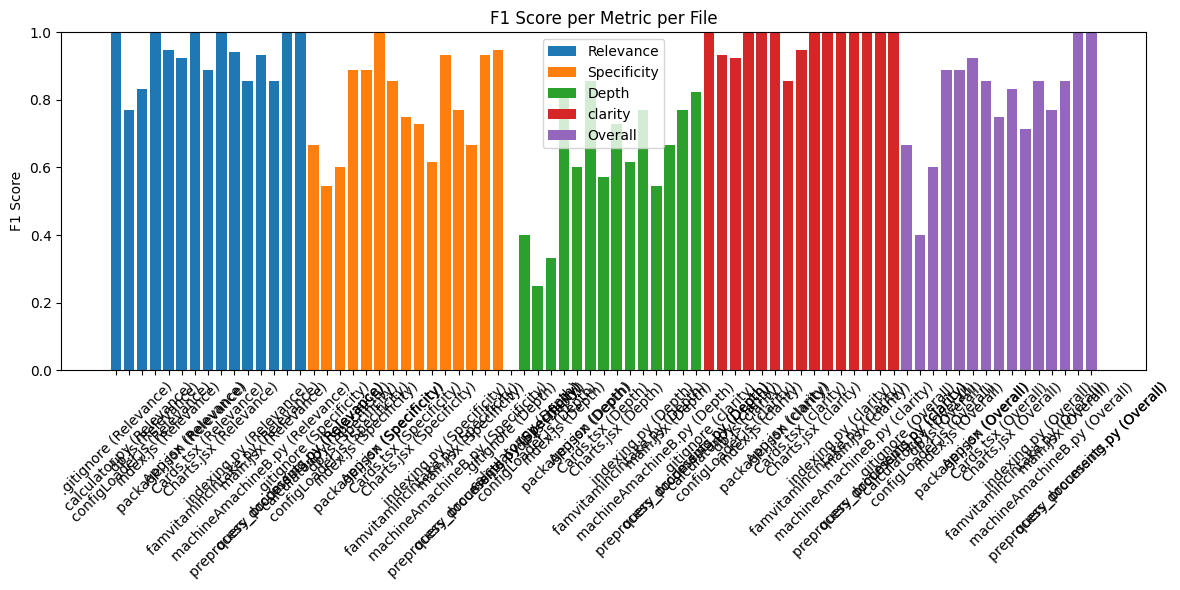

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# === Load JSON file ===
json_file = "manual_scores_Final.json"  # Replace with your JSON filename
with open(json_file, "r") as f:
    data = json.load(f)

# === Threshold to consider a score "good" ===
threshold = 4.0

metrics = ["Relevance", "Specificity", "Depth", "clarity", "Overall"]
file_metrics = []

# === Compute per-file metrics and F1/Precision/Recall per metric ===
for file_name, questions in data.items():
    metrics_list = []
    metric_results = {m: {"y_true": [], "y_pred": []} for m in metrics}
    
    for q in questions:
        scores = q["scores"]
        overall = sum(scores.values()) / len(scores)
        scores_with_overall = {**scores, "Overall": overall}
        metrics_list.append(scores_with_overall)
        
        # Populate true and predicted labels per metric
        for m in metrics:
            metric_results[m]["y_true"].append(1 if scores_with_overall[m] >= threshold else 0)
            metric_results[m]["y_pred"].append(1)  # assume model predicts all questions as "good"
    
    # Compute average metric values
    df = pd.DataFrame(metrics_list)
    avg_scores = df.mean().to_dict()
    
    # Compute F1, precision, recall per metric
    for m in metrics:
        precision = precision_score(metric_results[m]["y_true"], metric_results[m]["y_pred"])
        recall = recall_score(metric_results[m]["y_true"], metric_results[m]["y_pred"])
        f1 = f1_score(metric_results[m]["y_true"], metric_results[m]["y_pred"])
        avg_scores[f"{m}_Precision"] = precision
        avg_scores[f"{m}_Recall"] = recall
        avg_scores[f"{m}_F1"] = f1
    
    avg_scores["File"] = file_name
    file_metrics.append(avg_scores)

# === Convert to DataFrame ===
file_metrics_df = pd.DataFrame(file_metrics)
cols = ["File"] + metrics + [f"{m}_Precision" for m in metrics] + [f"{m}_Recall" for m in metrics] + [f"{m}_F1" for m in metrics]
file_metrics_df = file_metrics_df[cols]

print("=== Per-File Metrics with F1 per Metric ===")
print(file_metrics_df)

# === Compute global metrics per metric ===
all_scores = {m: [] for m in metrics}
y_true_global = {m: [] for m in metrics}
y_pred_global = {m: [] for m in metrics}

for questions in data.values():
    for q in questions:
        scores = q["scores"]
        overall = sum(scores.values()) / len(scores)
        scores_with_overall = {**scores, "Overall": overall}
        
        for m in metrics:
            all_scores[m].append(scores_with_overall[m])
            y_true_global[m].append(1 if scores_with_overall[m] >= threshold else 0)
            y_pred_global[m].append(1)

print("\n=== Global Metrics with F1 per Metric ===")
for m in metrics:
    avg_score = sum(all_scores[m]) / len(all_scores[m])
    precision = precision_score(y_true_global[m], y_pred_global[m])
    recall = recall_score(y_true_global[m], y_pred_global[m])
    f1 = f1_score(y_true_global[m], y_pred_global[m])
    print(f"{m}: Avg={avg_score:.2f}, Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")

# === Optional Visualization: F1 per metric per file ===
plt.figure(figsize=(12,6))
for i, m in enumerate(metrics):
    plt.bar([f"{f} ({m})" for f in file_metrics_df["File"]], file_metrics_df[f"{m}_F1"], label=m)
plt.title("F1 Score per Metric per File")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()
